In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Bangladesh Agroclimatic Crop Yield (2000-2024).csv to Bangladesh Agroclimatic Crop Yield (2000-2024).csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['Bangladesh Agroclimatic Crop Yield (2000-2024).csv']))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 15)

First 5 rows:


,Division,year,M.ton,hectares,Crop yield,Max temp,Min temp,Max Wind Speed,Min wind speed,Precipitation Corrected Sum,All Sky Surface Total PAR,Root Zone Soil Wetness,Surface Soil Wetness,Humidity,Earth Skin Temp
0,Chittagong,2000,1423336.570,515387.8553,2.761680,37.34,9.70,1.35,0.02,124.72,8.6300,0.4325,0.4000,9.1675,21.8000
1,Chittagong,2001,1444682.627,524970.8198,2.751929,39.05,6.85,1.37,0.03,75.77,8.3900,0.4150,0.3575,8.2800,21.9500
2,Chittagong,2002,1492781.562,534776.3616,2.791413,37.55,8.65,1.36,0.01,92.99,8.2325,0.4150,0.3600,8.9200,22.6300
3,Chittagong,2003,1598060.351,569737.1851,2.804908,38.40,8.92,1.23,0.00,104.90,8.3450,0.4200,0.3850,9.4225,22.0800
4,Chittagong,2004,1596853.795,560842.1868,2.847243,37.10,8.24,1.35,0.00,96.00,7.8375,0.4075,0.3350,9.5900,22.2425


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Column Names:
['Division', 'year', 'M.ton', 'hectares', 'Crop yield', 'Max temp', 'Min temp', 'Max Wind Speed', 'Min wind speed', 'Precipitation Corrected Sum', 'All Sky Surface Total PAR', 'Root Zone Soil Wetness', 'Surface Soil Wetness', 'Humidity', 'Earth Skin Temp']

Data Types:
Division                        object
year                             int64
M.ton                          float64
hectares                       float64
Crop yield                     float64
Max temp                       float64
Min temp                       float64
Max Wind Speed                 float64
Min wind speed                 float64
Precipitation Corrected Sum    float64
All Sky Surface Total PAR      float64
Root Zone Soil Wetness         float64
Surface Soil Wetness           float64
Humidity                       float64
Earth Skin Temp                float64
dtype: object

Basic Statistics:


,year,M.ton,hectares,Crop yield,Max temp,Min temp,Max Wind Speed,Min wind speed,Precipitation Corrected Sum,All Sky Surface Total PAR,Root Zone Soil Wetness,Surface Soil Wetness,Humidity,Earth Skin Temp
count,150.00000,1.500000e+02,1.500000e+02,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2012.00000,1.918970e+06,5.205909e+05,3.576897,39.691800,7.761067,5.132600,0.043000,197.473533,7.657767,0.491550,0.450683,10.010517,23.357967
std,7.23526,1.119998e+06,2.688822e+05,0.594414,2.950689,1.764122,2.055158,0.031934,170.312097,0.480740,0.061041,0.080470,1.627734,1.353209
min,2000.00000,1.903727e+05,4.267400e+04,2.030601,32.390000,1.670000,1.220000,0.000000,27.800000,6.525000,0.357500,0.262500,5.827500,20.755000
25%,2006.00000,9.252853e+05,3.490756e+05,3.076224,37.325000,6.640000,4.390000,0.020000,93.722500,7.343750,0.445625,0.395000,8.813750,22.250625
50%,2012.00000,1.838038e+06,5.432323e+05,3.726556,39.230000,7.545000,5.575000,0.040000,144.505000,7.652500,0.481250,0.436250,9.966250,23.265000
75%,2018.00000,2.687578e+06,6.664936e+05,4.071581,42.205000,9.040000,6.435000,0.060000,252.935000,7.994375,0.527500,0.496875,11.091875,24.390000
max,2024.00000,4.624167e+06,1.138858e+06,4.706972,47.140000,11.670000,9.130000,0.150000,1329.140000,9.025000,0.682500,0.707500,13.837500,26.830000


In [ ]:
print("Null Values per Column:")
print(df.isnull().sum())

print("\nTotal Null Values:", df.isnull().sum().sum())

Null Values per Column:
Division                       0
year                           0
M.ton                          0
hectares                       0
Crop yield                     0
Max temp                       0
Min temp                       0
Max Wind Speed                 0
Min wind speed                 0
Precipitation Corrected Sum    0
All Sky Surface Total PAR      0
Root Zone Soil Wetness         0
Surface Soil Wetness           0
Humidity                       0
Earth Skin Temp                0
dtype: int64

Total Null Values: 0


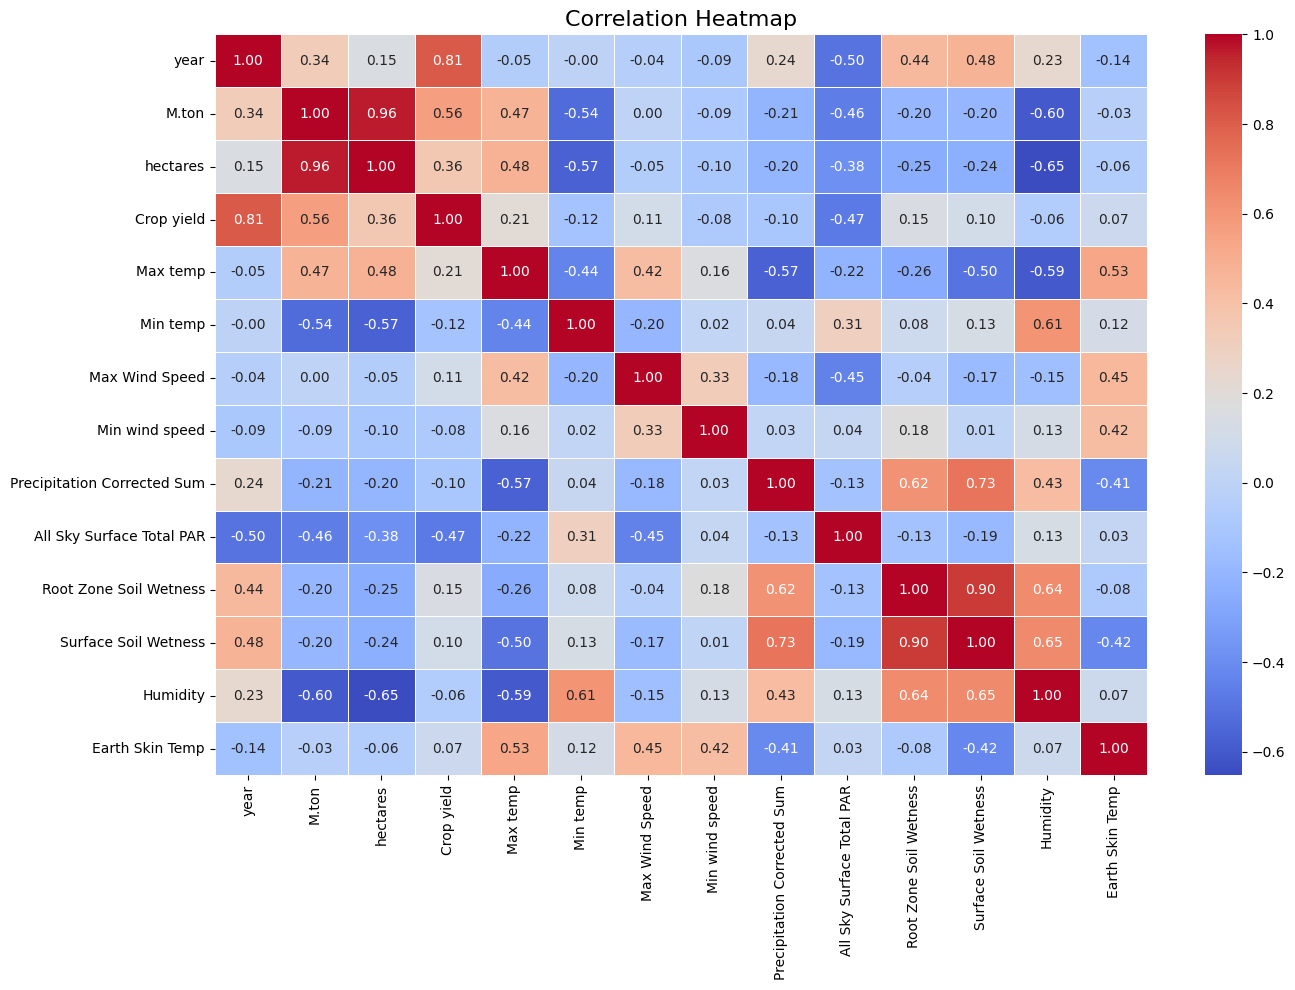

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Log transform
df['M.ton_log'] = np.log1p(df['M.ton'])

# Features
X = df[['year', 'hectares', 'Max temp', 'Min temp',
        'Max Wind Speed', 'Min wind speed',
        'Precipitation Corrected Sum',
        'All Sky Surface Total PAR',
        'Root Zone Soil Wetness', 'Surface Soil Wetness',
        'Humidity', 'Earth Skin Temp']]

# Targets
y = df[['Crop yield', 'M.ton_log']]

print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features Shape: (150, 12)
Target Shape: (150, 2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (120, 12)
X_test : (30, 12)
y_train: (120, 2)
y_test : (30, 2)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

models = {
    'XGBoost'          : MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', n_estimators=200, verbosity=0)),
    'Random Forest'    : MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42)),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, random_state=42)),
    'Linear Regression': MultiOutputRegressor(LinearRegression()),
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)

    cy_r2   = r2_score(y_test['Crop yield'], p[:, 0])
    cy_mae  = mean_absolute_error(y_test['Crop yield'], p[:, 0])
    cy_rmse = np.sqrt(mean_squared_error(y_test['Crop yield'], p[:, 0]))

    p_mton     = np.expm1(p[:, 1])
    yt_mton    = np.expm1(y_test['M.ton_log'])
    mt_r2   = r2_score(yt_mton, p_mton)
    mt_mae  = mean_absolute_error(yt_mton, p_mton)
    mt_rmse = np.sqrt(mean_squared_error(yt_mton, p_mton))

    results.append({
        'Model'         : name,
        'CY R²'         : round(cy_r2, 4),
        'CY MAE'        : round(cy_mae, 4),
        'CY RMSE'       : round(cy_rmse, 4),
        'Prod R²'       : round(mt_r2, 4),
        'Prod MAE'      : round(mt_mae, 0),
        'Prod RMSE'     : round(mt_rmse, 0),
    })

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))



            Model  CY R²  CY MAE  CY RMSE  Prod R²  Prod MAE  Prod RMSE
          XGBoost 0.8537  0.1667   0.2406   0.9838   95267.0   156459.0
    Random Forest 0.8783  0.1627   0.2195   0.9911   73851.0   115659.0
Gradient Boosting 0.9054  0.1489   0.1935   0.9936   75873.0    97876.0
Linear Regression 0.8014  0.2279   0.2804   0.8635  260788.0   453566.0


In [ ]:

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


print("Step 1: Out-of-fold XGBoost predictions generating...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

meta_crop_yield = np.zeros(len(X))
meta_mton       = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    fold_model = MultiOutputRegressor(
        XGBRegressor(
            objective='reg:squarederror',
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        )
    )
    fold_model.fit(X_fold_train, y_fold_train)
    fold_pred = fold_model.predict(X_fold_val)

    meta_crop_yield[val_idx] = fold_pred[:, 0]
    meta_mton[val_idx]       = np.expm1(fold_pred[:, 1])
    print(f"  Fold {fold+1}/5 done")

print("Out-of-fold predictions ready!\n")

X_meta = X.copy()
X_meta['XGB_pred_CropYield'] = meta_crop_yield
X_meta['XGB_pred_Mton']      = meta_mton

print(f"Original features : {X.shape[1]}")
print(f"After meta-features: {X_meta.shape[1]}")
print(f"New features added: XGB_pred_CropYield, XGB_pred_Mton\n")

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_meta, y, test_size=0.2, random_state=42
)

print(f"X_train_meta: {X_train_m.shape}")
print(f"X_test_meta : {X_test_m.shape}\n")

models_meta = {
    'XGBoost + Meta'          : MultiOutputRegressor(XGBRegressor(
                                    objective='reg:squarederror', n_estimators=200,
                                    learning_rate=0.05, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0)),
    'Random Forest + Meta'    : MultiOutputRegressor(RandomForestRegressor(
                                    n_estimators=200, random_state=42)),
    'Gradient Boosting + Meta': MultiOutputRegressor(GradientBoostingRegressor(
                                    n_estimators=200, random_state=42)),
    'Linear Regression + Meta': MultiOutputRegressor(LinearRegression()),
}

results_meta = []

for name, m in models_meta.items():
    m.fit(X_train_m, y_train_m)
    p = m.predict(X_test_m)

    cy_r2   = r2_score(y_test_m['Crop yield'], p[:, 0])
    cy_mae  = mean_absolute_error(y_test_m['Crop yield'], p[:, 0])
    cy_rmse = np.sqrt(mean_squared_error(y_test_m['Crop yield'], p[:, 0]))

    p_mton  = np.expm1(p[:, 1])
    yt_mton = np.expm1(y_test_m['M.ton_log'])
    mt_r2   = r2_score(yt_mton, p_mton)
    mt_mae  = mean_absolute_error(yt_mton, p_mton)
    mt_rmse = np.sqrt(mean_squared_error(yt_mton, p_mton))

    results_meta.append({
        'Model'    : name,
        'CY R²'   : round(cy_r2, 4),
        'CY MAE'  : round(cy_mae, 4),
        'CY RMSE' : round(cy_rmse, 4),
        'Prod R²' : round(mt_r2, 4),
        'Prod MAE': round(mt_mae, 0),
        'Prod RMSE': round(mt_rmse, 0),
    })
    print(f"{name}: CY R²={cy_r2:.4f} | Prod R²={mt_r2:.4f}")

print("\n" + "="*65)
print("BEFORE vs AFTER META-FEATURE (Gradient Boosting comparison)")
print("="*65)

df_meta = pd.DataFrame(results_meta)
print(df_meta.to_string(index=False))

before = {
    'XGBoost'          : {'CY R²': 0.8537, 'Prod R²': 0.9838},
    'Random Forest'    : {'CY R²': 0.8783, 'Prod R²': 0.9911},
    'Gradient Boosting': {'CY R²': 0.9054, 'Prod R²': 0.9936},
    'Linear Regression': {'CY R²': 0.8014, 'Prod R²': 0.8635},
}

print("\n" + "="*65)
print("IMPROVEMENT SUMMARY (After - Before)")
print("="*65)
for row in results_meta:
    model_base = row['Model'].replace(' + Meta', '')
    if model_base in before:
        cy_diff   = row['CY R²'] - before[model_base]['CY R²']
        prod_diff = row['Prod R²'] - before[model_base]['Prod R²']
        arrow_cy   = "▲" if cy_diff > 0 else "▼"
        arrow_prod = "▲" if prod_diff > 0 else "▼"
        print(f"{model_base:20s}: CY R² {arrow_cy}{cy_diff:+.4f} | Prod R² {arrow_prod}{prod_diff:+.4f}")

Step 1: Out-of-fold XGBoost predictions generating...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
Out-of-fold predictions ready!

Original features : 12
After meta-features: 14
New features added: XGB_pred_CropYield, XGB_pred_Mton

X_train_meta: (120, 14)
X_test_meta : (30, 14)

XGBoost + Meta: CY R²=0.8568 | Prod R²=0.9862
Random Forest + Meta: CY R²=0.8701 | Prod R²=0.9797
Gradient Boosting + Meta: CY R²=0.8919 | Prod R²=0.9922
Linear Regression + Meta: CY R²=0.9125 | Prod R²=0.7787

BEFORE vs AFTER META-FEATURE (Gradient Boosting comparison)
                   Model  CY R²  CY MAE  CY RMSE  Prod R²  Prod MAE  Prod RMSE
          XGBoost + Meta 0.8568  0.1688   0.2381   0.9862   92962.0   144160.0
    Random Forest + Meta 0.8701  0.1595   0.2268   0.9797  108895.0   174888.0
Gradient Boosting + Meta 0.8919  0.1466   0.2068   0.9922   78161.0   108150.0
Linear Regression + Meta 0.9125  0.1438   0.1861   0.7787  323251.0   577426.0

IMPROVEMENT SUMMA

In [ ]:
# Final Model Evaluation (Meta-feature XGBoost)
best_model = MultiOutputRegressor(XGBRegressor(
    objective='reg:squarederror', n_estimators=200,
    learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
))
best_model.fit(X_train_m, y_train_m)
p = best_model.predict(X_test_m)

p_mton  = np.expm1(p[:, 1])
yt_mton = np.expm1(y_test_m['M.ton_log'])

print("===== Final Model (XGBoost + Meta) =====")
print("\nCrop Yield")
print("R²  :", round(r2_score(y_test_m['Crop yield'], p[:, 0]), 4))
print("MAE :", round(mean_absolute_error(y_test_m['Crop yield'], p[:, 0]), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test_m['Crop yield'], p[:, 0])), 4))

print("\nProduction (M.ton)")
print("R²  :", round(r2_score(yt_mton, p_mton), 4))
print("MAE :", round(mean_absolute_error(yt_mton, p_mton), 0))
print("RMSE:", round(np.sqrt(mean_squared_error(yt_mton, p_mton)), 0))

===== Final Model (XGBoost + Meta) =====

Crop Yield
R²  : 0.8568
MAE : 0.1688
RMSE: 0.2381

Production (M.ton)
R²  : 0.9862
MAE : 92962.0
RMSE: 144160.0


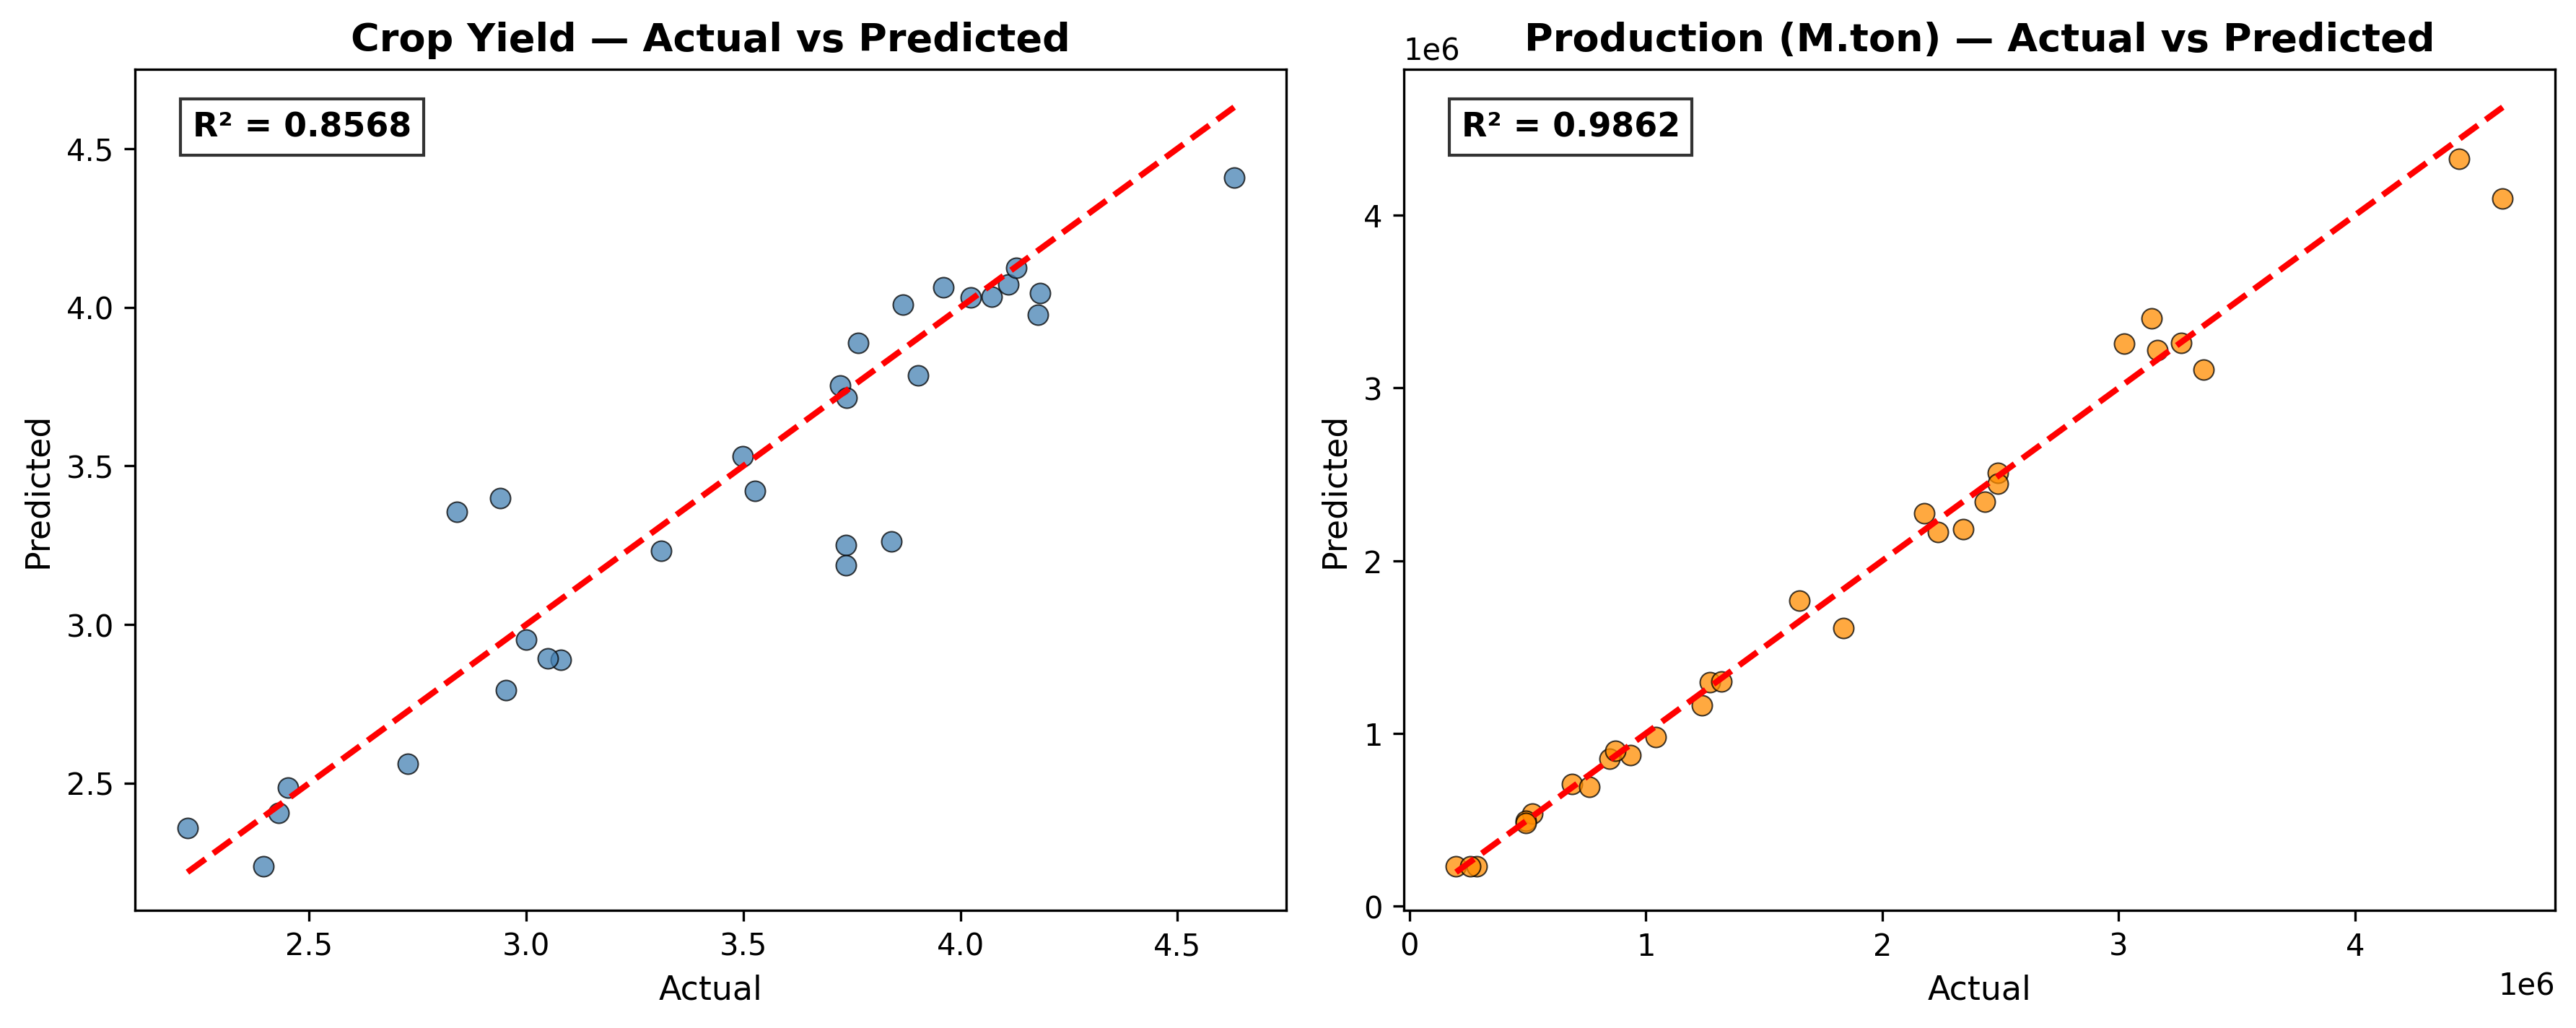

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# High resolution figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Crop Yield
axes[0].scatter(
    y_test_m['Crop yield'],
    p[:, 0],
    color='steelblue',
    alpha=0.75,
    s=45,                 # Marker size
    edgecolors='black',   # Marker border
    linewidth=0.5
)

axes[0].plot(
    [y_test_m['Crop yield'].min(), y_test_m['Crop yield'].max()],
    [y_test_m['Crop yield'].min(), y_test_m['Crop yield'].max()],
    'r--',
    linewidth=2
)

axes[0].set_title('Crop Yield — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual', fontsize=11)
axes[0].set_ylabel('Predicted', fontsize=11)
axes[0].tick_params(labelsize=10)

axes[0].text(
    0.05, 0.95,
    f'R² = {r2_score(y_test_m["Crop yield"], p[:,0]):.4f}',
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

# Production
axes[1].scatter(
    yt_mton,
    p_mton,
    color='darkorange',
    alpha=0.75,
    s=45,
    edgecolors='black',
    linewidth=0.5
)

axes[1].plot(
    [yt_mton.min(), yt_mton.max()],
    [yt_mton.min(), yt_mton.max()],
    'r--',
    linewidth=2
)

axes[1].set_title('Production (M.ton) — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual', fontsize=11)
axes[1].set_ylabel('Predicted', fontsize=11)
axes[1].tick_params(labelsize=10)

axes[1].text(
    0.05, 0.95,
    f'R² = {r2_score(yt_mton, p_mton):.4f}',
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.tight_layout()

# Save in high quality
plt.savefig(
    "Actual_vs_Predicted_HD.png",
    dpi=600,
    bbox_inches='tight'
)

# Optional: PDF version (best for conference papers)
plt.savefig(
    "Actual_vs_Predicted_HD.pdf",
    bbox_inches='tight'
)

plt.show()

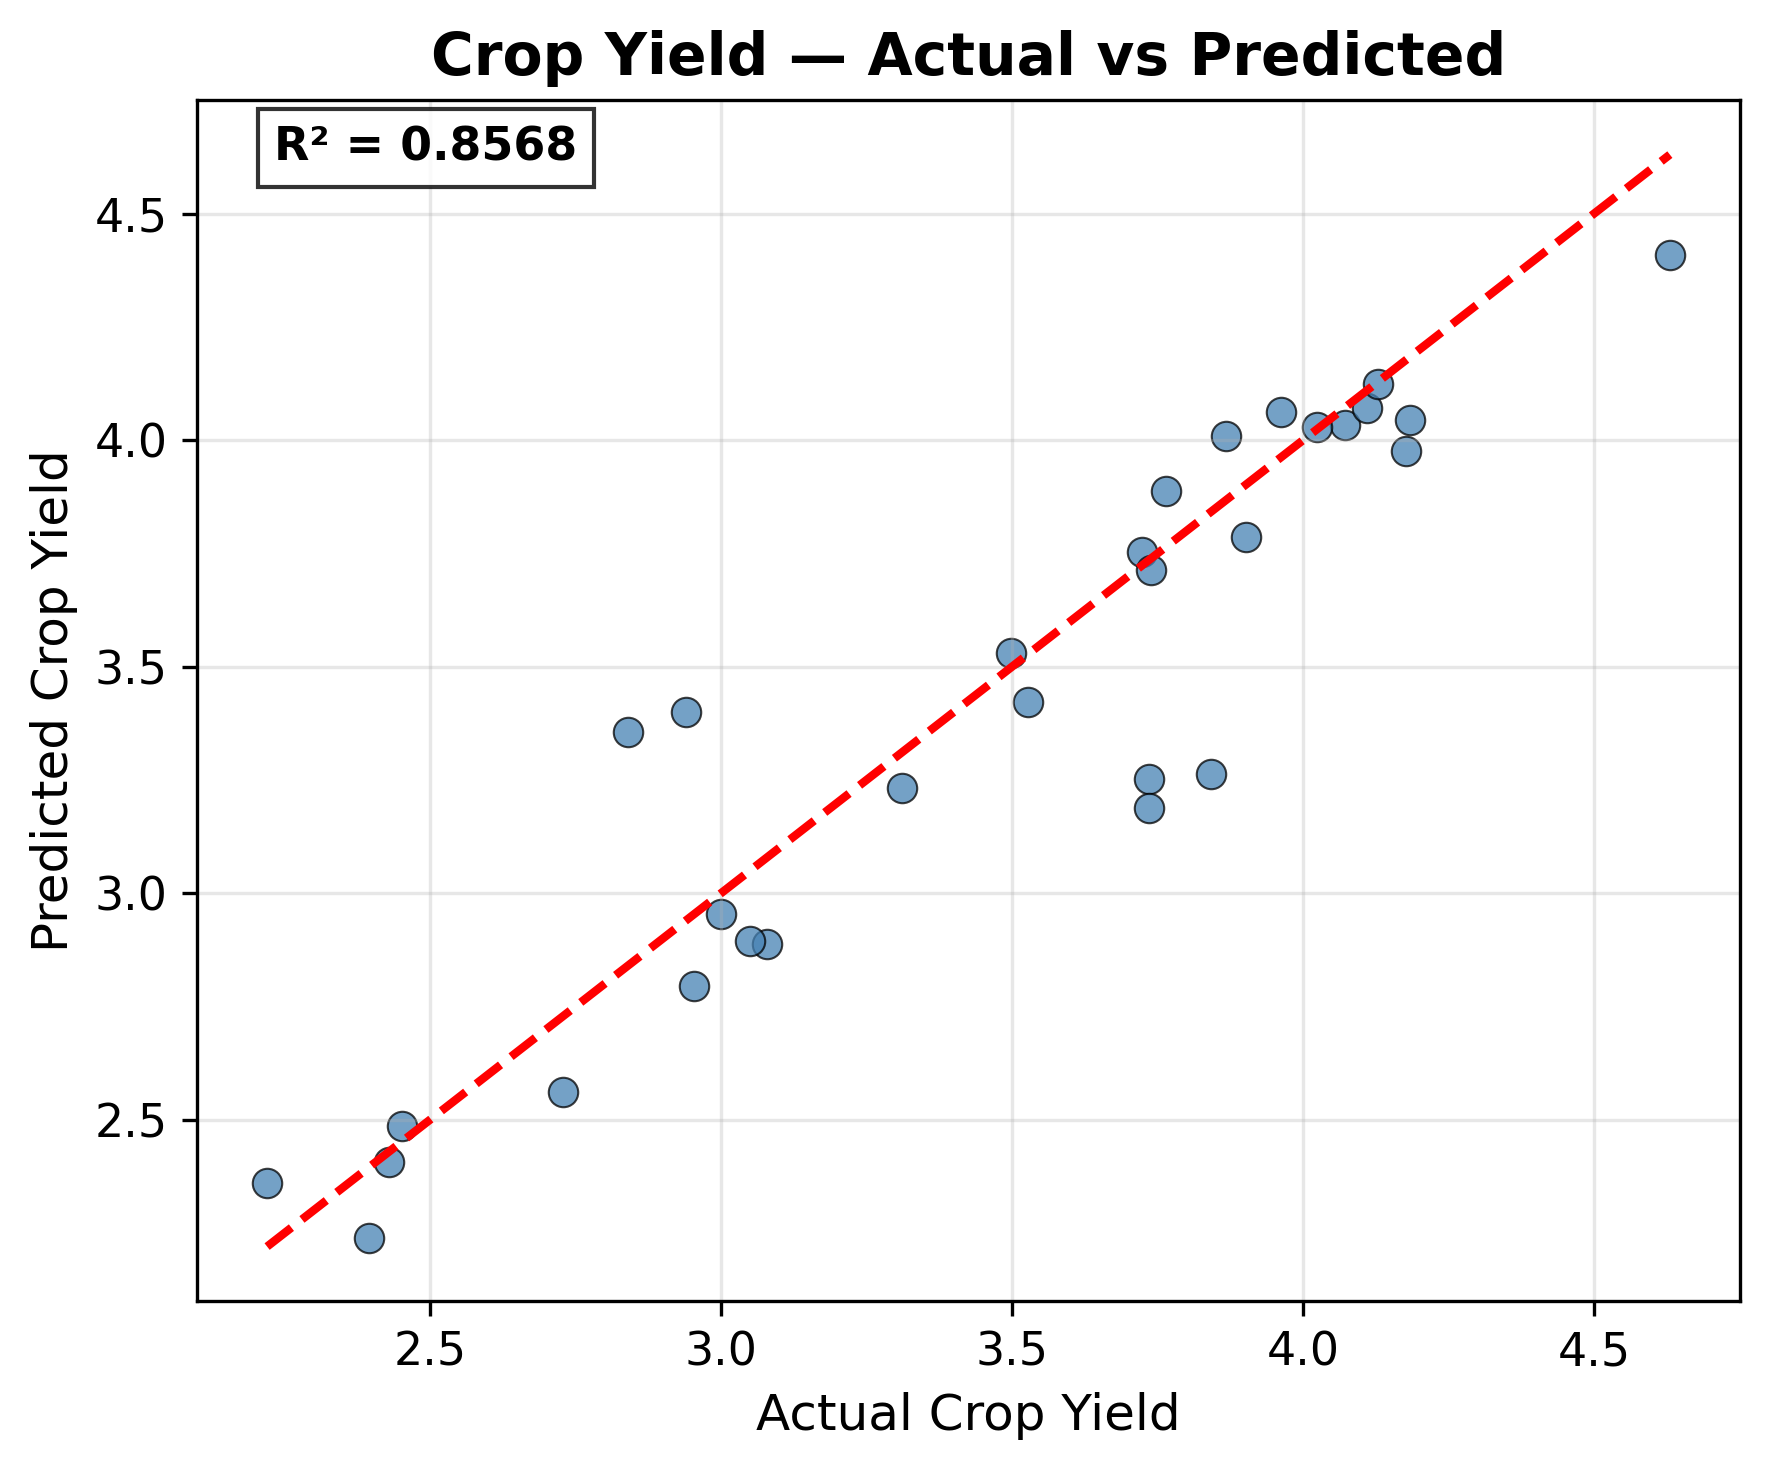

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.figure(figsize=(6, 5), dpi=300)

plt.scatter(
    y_test_m['Crop yield'],
    p[:, 0],
    color='steelblue',
    alpha=0.75,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

plt.plot(
    [y_test_m['Crop yield'].min(), y_test_m['Crop yield'].max()],
    [y_test_m['Crop yield'].min(), y_test_m['Crop yield'].max()],
    'r--',
    linewidth=2
)

plt.title('Crop Yield — Actual vs Predicted',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Crop Yield', fontsize=12)
plt.ylabel('Predicted Crop Yield', fontsize=12)
plt.tick_params(labelsize=11)

plt.text(
    0.05, 0.95,
    f'R² = {r2_score(y_test_m["Crop yield"], p[:,0]):.4f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Crop_Yield_Actual_vs_Predicted.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

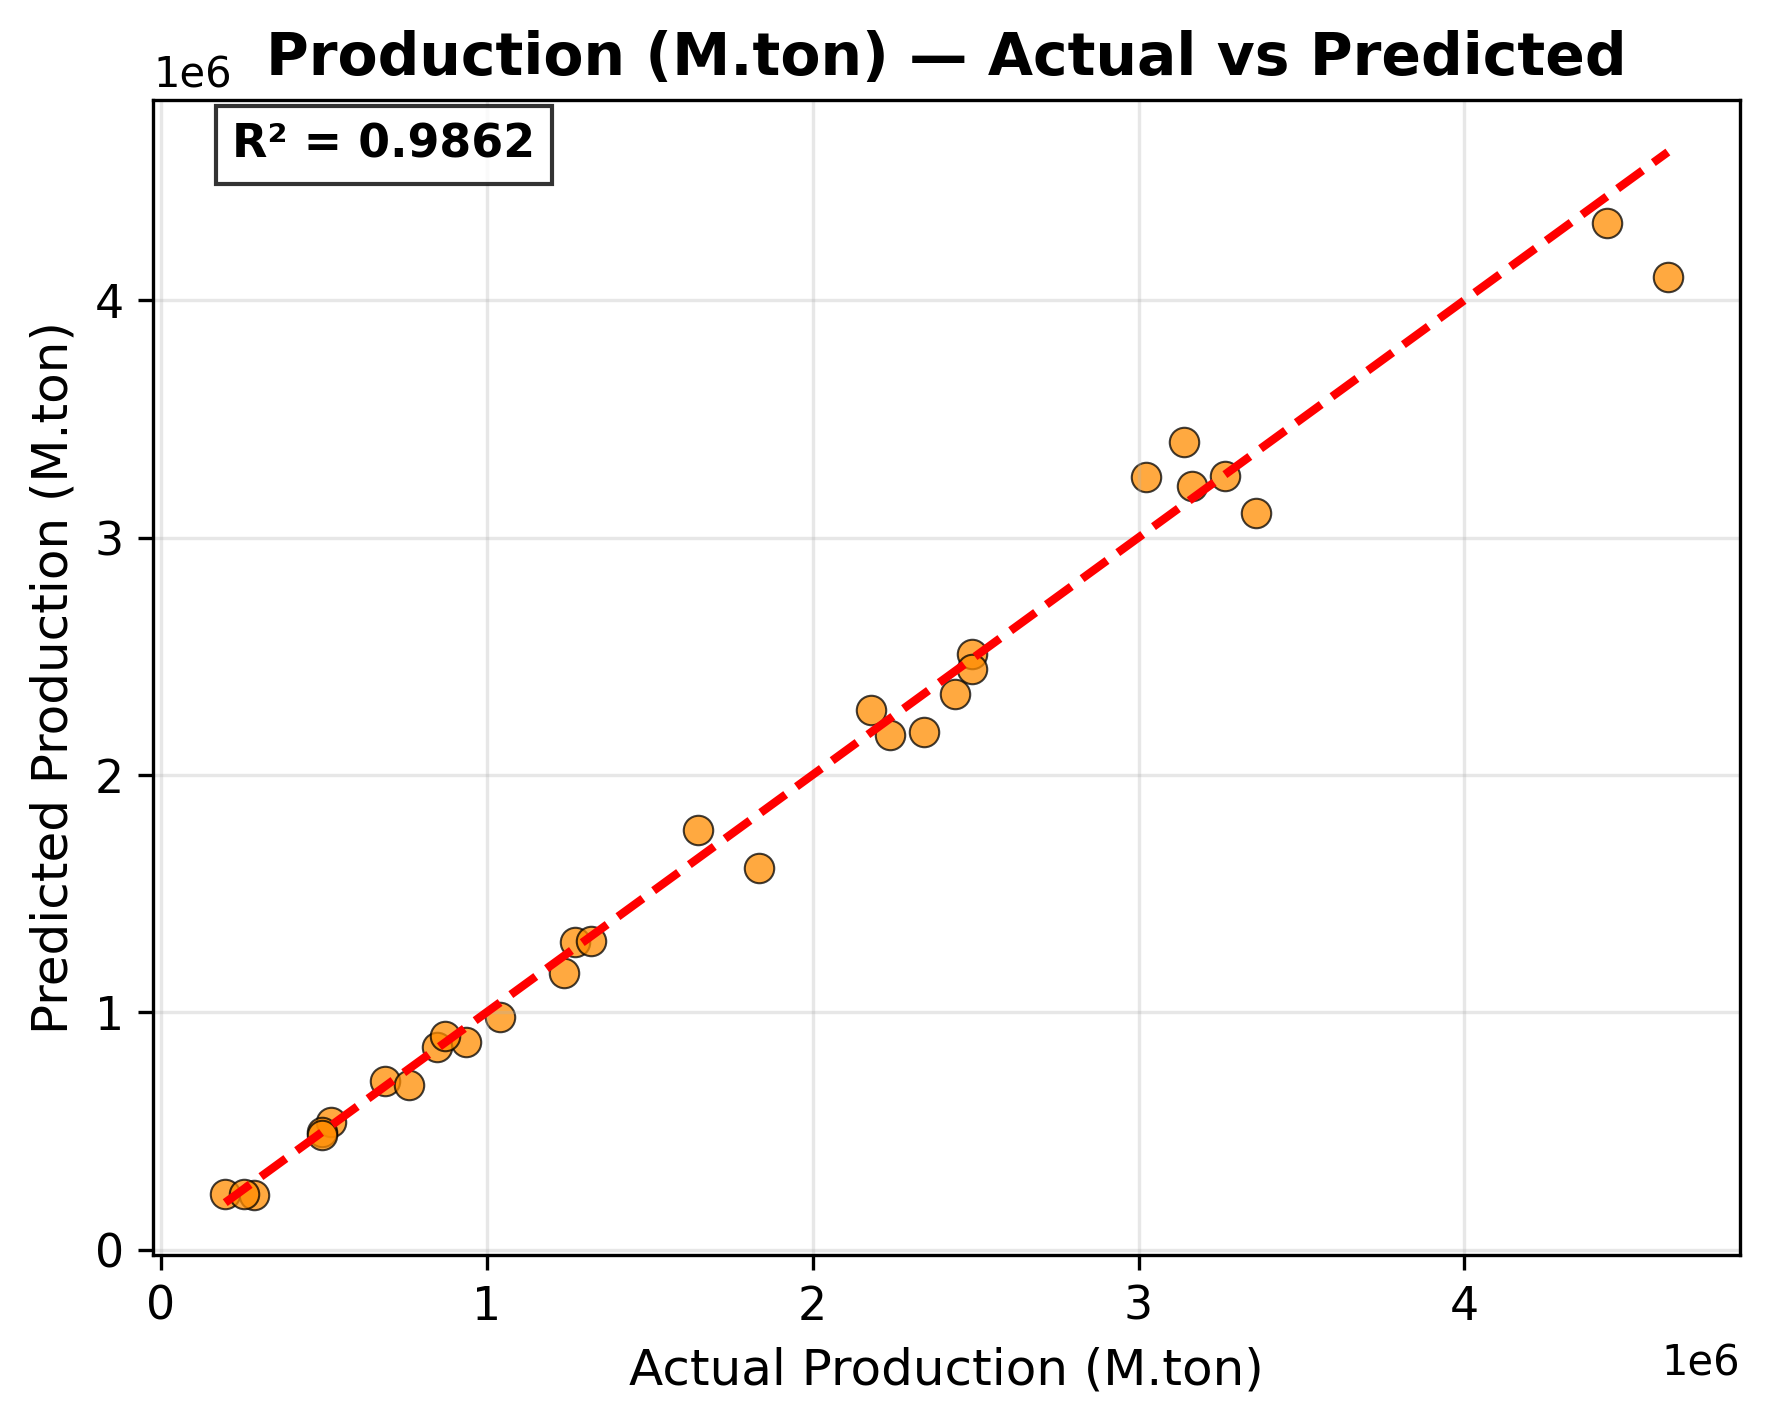

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.figure(figsize=(6, 5), dpi=300)

plt.scatter(
    yt_mton,
    p_mton,
    color='darkorange',
    alpha=0.75,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

plt.plot(
    [yt_mton.min(), yt_mton.max()],
    [yt_mton.min(), yt_mton.max()],
    'r--',
    linewidth=2
)

plt.title('Production (M.ton) — Actual vs Predicted',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Production (M.ton)', fontsize=12)
plt.ylabel('Predicted Production (M.ton)', fontsize=12)
plt.tick_params(labelsize=11)

plt.text(
    0.05, 0.95,
    f'R² = {r2_score(yt_mton, p_mton):.4f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Production_Actual_vs_Predicted.png",
            dpi=600,
            bbox_inches='tight')

plt.show()

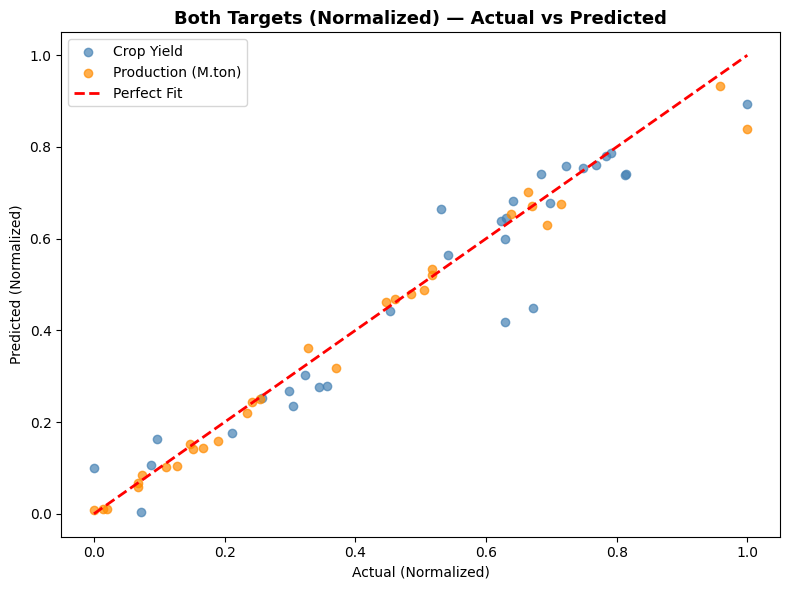

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cy_actual = scaler.fit_transform(y_test_m['Crop yield'].values.reshape(-1,1)).flatten()
cy_pred   = scaler.transform(p[:, 0].reshape(-1,1)).flatten()

scaler2 = MinMaxScaler()
mt_actual = scaler2.fit_transform(yt_mton.values.reshape(-1,1)).flatten()
mt_pred   = scaler2.transform(p_mton.reshape(-1,1)).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(cy_actual, cy_pred, color='steelblue', alpha=0.7, label='Crop Yield')
plt.scatter(mt_actual, mt_pred, color='darkorange', alpha=0.7, label='Production (M.ton)')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Fit')
plt.title('Both Targets (Normalized) — Actual vs Predicted', fontsize=13, fontweight='bold')
plt.xlabel('Actual (Normalized)')
plt.ylabel('Predicted (Normalized)')
plt.legend()
plt.tight_layout()
plt.show()

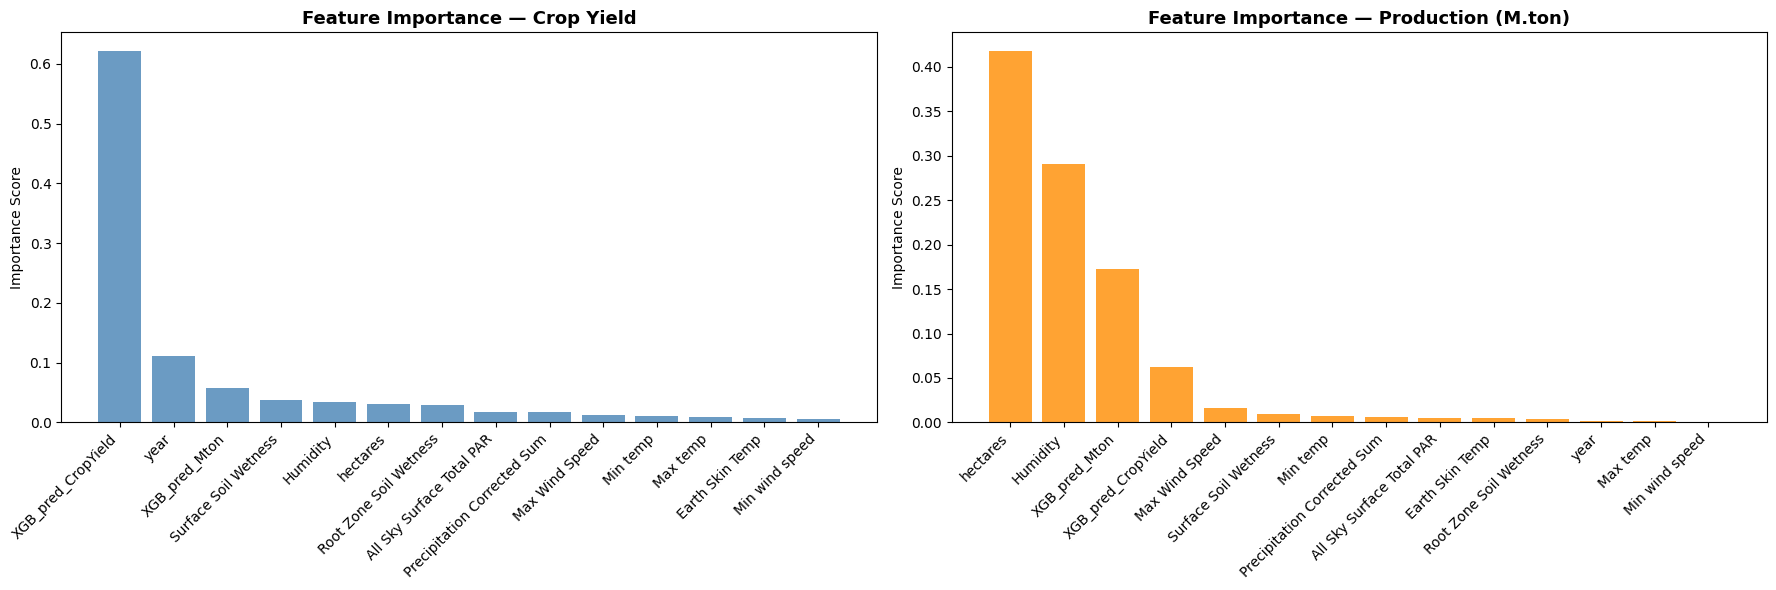

In [ ]:
feature_names = list(X_train_m.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Crop Yield
cy_model = best_model.estimators_[0]
cy_imp   = cy_model.feature_importances_
cy_idx   = np.argsort(cy_imp)[::-1]

axes[0].bar(range(len(feature_names)), cy_imp[cy_idx], color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_xticklabels([feature_names[i] for i in cy_idx], rotation=45, ha='right')
axes[0].set_title('Feature Importance — Crop Yield', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Importance Score')

# Production
mt_model = best_model.estimators_[1]
mt_imp   = mt_model.feature_importances_
mt_idx   = np.argsort(mt_imp)[::-1]

axes[1].bar(range(len(feature_names)), mt_imp[mt_idx], color='darkorange', alpha=0.8)
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels([feature_names[i] for i in mt_idx], rotation=45, ha='right')
axes[1].set_title('Feature Importance — Production (M.ton)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

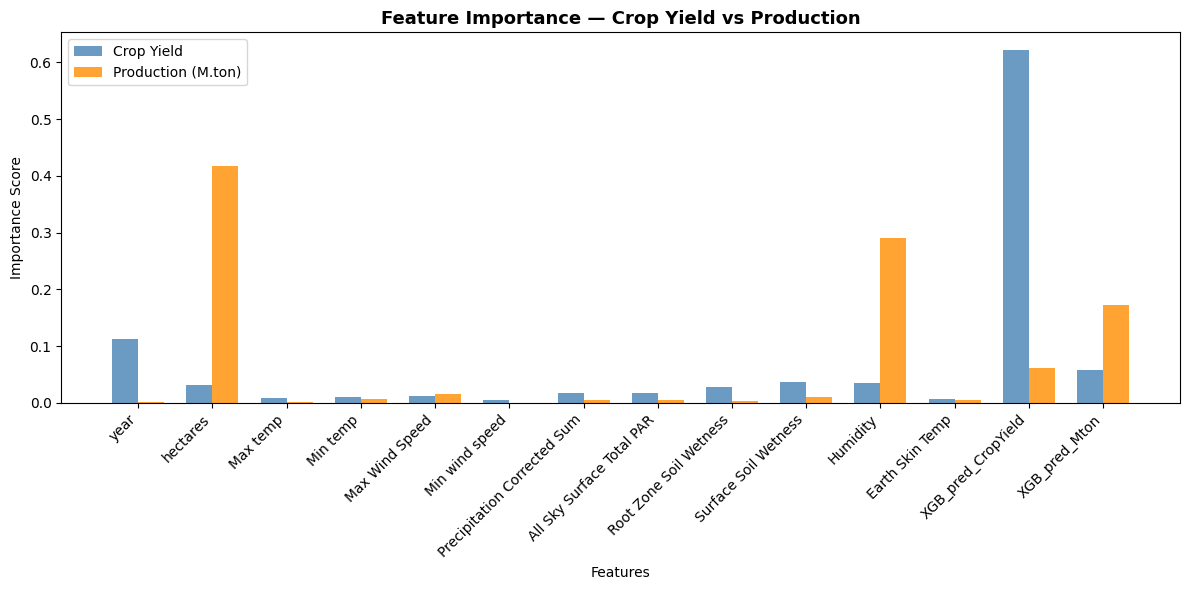

In [ ]:
feature_names = list(X_train_m.columns)

cy_model = best_model.estimators_[0]
mt_model = best_model.estimators_[1]

cy_imp = cy_model.feature_importances_
mt_imp = mt_model.feature_importances_

plt.figure(figsize=(12, 6))
x = np.arange(len(feature_names))
width = 0.35

plt.bar(x - width/2, cy_imp, width, color='steelblue', alpha=0.8, label='Crop Yield')
plt.bar(x + width/2, mt_imp, width, color='darkorange', alpha=0.8, label='Production (M.ton)')
plt.xticks(x, feature_names, rotation=45, ha='right')
plt.title('Feature Importance — Crop Yield vs Production', fontsize=13, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

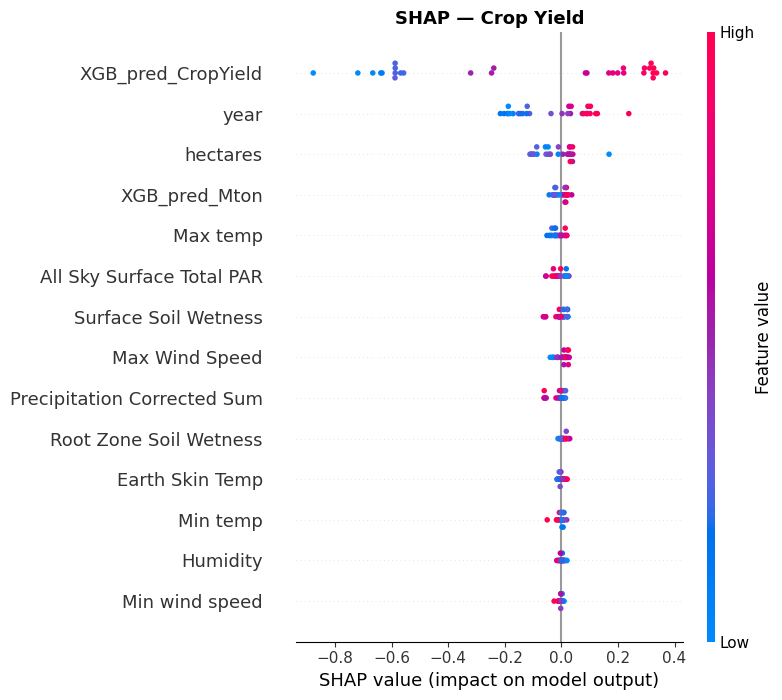

In [ ]:
import shap

# Crop Yield SHAP
explainer_cy = shap.TreeExplainer(best_model.estimators_[0])
shap_val_cy  = explainer_cy.shap_values(X_test_m)

plt.figure(figsize=(7, 3))
shap.summary_plot(shap_val_cy, X_test_m, show=False)
plt.title('SHAP — Crop Yield', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



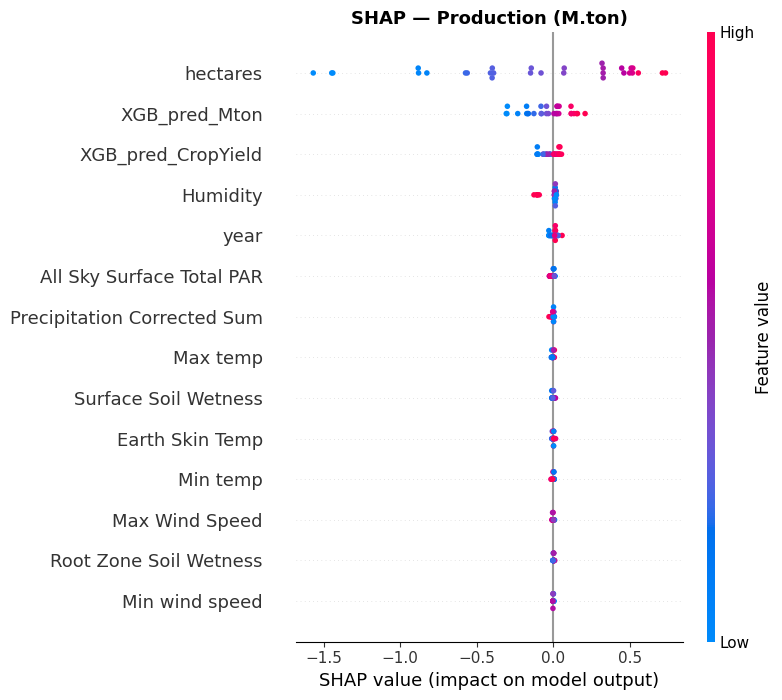

In [ ]:

import shap

# Production SHAP
explainer_mt = shap.TreeExplainer(best_model.estimators_[1])
shap_val_mt  = explainer_mt.shap_values(X_test_m)

plt.figure(figsize=(7, 3))
shap.summary_plot(shap_val_mt, X_test_m, show=False)
plt.title('SHAP — Production (M.ton)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

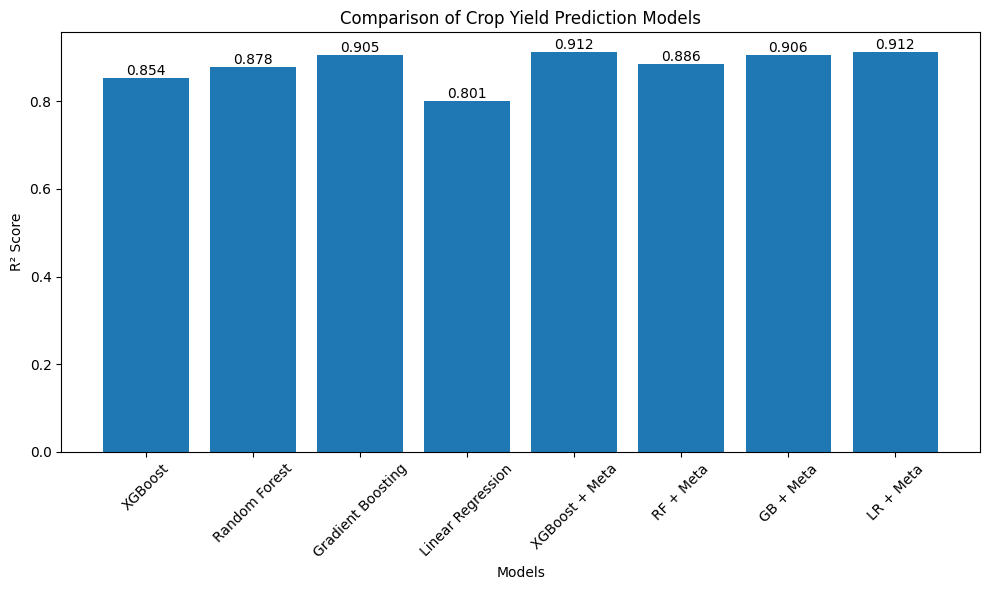

In [ ]:
import matplotlib.pyplot as plt

models = [
    'XGBoost',
    'Random Forest',
    'Gradient Boosting',
    'Linear Regression',
    'XGBoost + Meta',
    'RF + Meta',
    'GB + Meta',
    'LR + Meta'
]

r2_scores = [
    0.8537,
    0.8783,
    0.9054,
    0.8014,
    0.9117,
    0.8861,
    0.9057,
    0.9116
]

plt.figure(figsize=(10,6))
bars = plt.bar(models, r2_scores)

plt.ylabel('R² Score')
plt.xlabel('Models')
plt.title('Comparison of Crop Yield Prediction Models')
plt.xticks(rotation=45)

# Score show on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{y:.3f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()